# A 2D VAE on MNIST

Practice 05 - Generative Learning

Ulf Krumnack (Universität Osnabrück)  
Robin Rawiel (Universität Osnabrück)

This notebook keeps the VAE deliberately small. The bottleneck has only
two latent dimensions, which is worse for reconstruction quality than a
larger latent space but much better for understanding what the model is
doing. The goal here is interpretation, not leaderboard performance.

If Notebook 1 introduced the ELBO abstractly, this notebook shows where
the same logic appears in a neural model. The encoder now learns the
guide distribution $q_\phi(z \mid x)$, the decoder models
$p_\theta(x \mid z)$, and training still balances two goals: fit the
current image well and keep the latent distribution close to a
standard-normal prior that we can sample from later.

A plain autoencoder solves a simpler problem. It maps each image to one
deterministic latent code and trains only for reconstruction. A VAE adds
two extra ingredients: the encoder predicts a distribution over
plausible latent codes, and the loss includes a KL term that keeps those
latent distributions close to a simple prior. That usually makes a VAE
less sharp than a plain autoencoder of the same size, but much more
useful for sampling, interpolation, and generative modeling.

One notation detail is important from the start: the ELBO itself is a
quantity to maximize,

$$
\mathrm{ELBO}(x) = \mathbb{E}_{q(z \mid x)}[\log p(x \mid z)] - D_{\mathrm{KL}}(q(z \mid x)\,\|\,p(z)).
$$

The helper function below will return the corresponding training loss to
minimize, namely the negative ELBO. That is why the KL term appears with
a plus sign in code.

In [2]:
import numpy as np
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import ipywidgets as widgets

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 13,
    "figure.dpi": 100,
})

np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

using device: cpu


## Setup and helper functions

In [3]:
TRAIN_LIMIT = 5000
TEST_LIMIT = 1000
BATCH_SIZE = 128
LATENT_DIM = 2
HIDDEN_DIM = 192
EPOCHS = 6

transform = transforms.ToTensor()
train_full = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_full = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_subset = Subset(train_full, range(TRAIN_LIMIT))
test_subset = Subset(test_full, range(TEST_LIMIT))

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=256, shuffle=False)


def collect_examples_by_digit(dataset, digits):
    remaining = list(digits)
    images = []
    labels = []
    for image, label in dataset:
        if label in remaining:
            images.append(image)
            labels.append(label)
            remaining.remove(label)
        if not remaining:
            break
    return torch.stack(images), np.array(labels)


def show_image_rows(rows, row_labels, title):
    n_rows = len(rows)
    n_cols = rows[0].shape[0]
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.4 * n_cols, 1.6 * n_rows))
    axes = np.atleast_2d(axes)
    for row_idx, images in enumerate(rows):
        for col_idx in range(n_cols):
            axes[row_idx, col_idx].imshow(images[col_idx, 0], cmap="gray")
            axes[row_idx, col_idx].axis("off")
        axes[row_idx, 0].set_ylabel(row_labels[row_idx])
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def negative_elbo_loss(x_hat, x, mu, logvar, beta=1.0):
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon + beta * kl, recon, kl


def collect_latent_means(model, loader):
    model.eval()
    codes = []
    labels = []
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            mu, _ = model.encode(images)
            codes.append(mu.cpu())
            labels.append(targets)
    return torch.cat(codes).numpy(), torch.cat(labels).numpy()


def decode_grid(model, z_min=-2.8, z_max=2.8, steps=13):
    grid_x = np.linspace(z_min, z_max, steps)
    grid_y = np.linspace(z_max, z_min, steps)
    canvas = np.zeros((28 * steps, 28 * steps))

    with torch.no_grad():
        for row, z2 in enumerate(grid_y):
            for col, z1 in enumerate(grid_x):
                z = torch.tensor([[z1, z2]], dtype=torch.float32, device=device)
                decoded = model.decode(z).cpu().view(28, 28).numpy()
                canvas[row * 28 : (row + 1) * 28, col * 28 : (col + 1) * 28] = decoded

    plt.figure(figsize=(8, 8))
    plt.imshow(canvas, cmap="gray")
    plt.title("Decoder output across the 2D latent plane")
    plt.xticks(np.arange(14, 28 * steps, 28), [f"{z:.1f}" for z in grid_x], rotation=90)
    plt.yticks(np.arange(14, 28 * steps, 28), [f"{z:.1f}" for z in grid_y])
    plt.xlabel("latent coordinate z1")
    plt.ylabel("latent coordinate z2")
    plt.tight_layout()
    plt.show()

The helper code already contains most of the VAE story:

- `negative_elbo_loss` is not the ELBO itself. It is the loss obtained
  by negating the ELBO, so the binary cross-entropy acts as a positive
  reconstruction loss and the closed-form Gaussian KL term is added as a
  penalty.
- `collect_latent_means` uses `mu` rather than noisy latent samples
  because we want to inspect the learned geometry, not the randomness
  injected during training.
- `decode_grid` asks whether the decoder gives meaningful outputs across
  the latent plane instead of only at exact training codes.

The reduction choice in `negative_elbo_loss` matters. Both terms are
summed over features and then normalized by the batch size, so their
relative scale stays interpretable. Maximizing the ELBO and minimizing
this loss are equivalent; they are just two sign conventions for the
same optimization problem.

train subset size: 5000
test subset size: 1000
example batch shape: (6, 1, 28, 28)


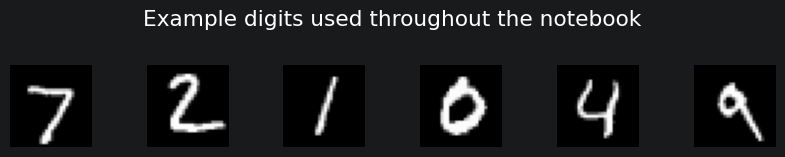

In [4]:
example_batch, example_labels = collect_examples_by_digit(test_subset, [0, 1, 2, 4, 7, 9])
print("train subset size:", len(train_subset))
print("test subset size:", len(test_subset))
print("example batch shape:", tuple(example_batch.shape))

show_image_rows([example_batch.numpy()], ["digit"], "Example digits used throughout the notebook")

## A compact two-dimensional VAE

In [5]:
class TinyVAE(nn.Module):
    def __init__(self, latent_dim=2, hidden_dim=192):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 28 * 28),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


def train_vae(model, loader, epochs=6, lr=1e-3, beta=1.0):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"total": [], "recon": [], "kl": []}

    for epoch in range(epochs):
        model.train()
        running_total = 0.0
        running_recon = 0.0
        running_kl = 0.0
        for images, _ in loader:
            images = images.to(device)
            x_hat, mu, logvar = model(images)
            total_loss, recon_loss, kl_loss = negative_elbo_loss(x_hat, images, mu, logvar, beta=beta)

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            running_total += total_loss.item()
            running_recon += recon_loss.item()
            running_kl += kl_loss.item()

        n_batches = len(loader)
        history["total"].append(running_total / n_batches)
        history["recon"].append(running_recon / n_batches)
        history["kl"].append(running_kl / n_batches)
        print(
            f"epoch {epoch + 1:02d} | total = {history['total'][-1]:.3f} | "
            f"recon = {history['recon'][-1]:.3f} | kl = {history['kl'][-1]:.3f}"
        )

    return history

The most important non-obvious step above is `reparameterize`. We do not
sample $z$ as an opaque random variable and stop there. Instead we write

$$
z = \mu + \sigma \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I).
$$

The noise stays random, but gradients can still flow through $\mu$ and
$\sigma$ back into the encoder. That is why VAEs can combine stochastic
latent variables with standard backpropagation.

In [6]:
vae = TinyVAE(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM).to(device)
history = train_vae(vae, train_loader, epochs=EPOCHS)

epoch 01 | total = 305.840 | recon = 304.510 | kl = 1.330
epoch 02 | total = 207.061 | recon = 206.455 | kl = 0.605
epoch 03 | total = 198.407 | recon = 196.155 | kl = 2.252
epoch 04 | total = 193.434 | recon = 191.112 | kl = 2.322
epoch 05 | total = 190.641 | recon = 188.162 | kl = 2.479
epoch 06 | total = 188.442 | recon = 185.964 | kl = 2.478


The small latent dimension makes the task intentionally difficult. If
the reconstructions are not perfect, that is not automatically a bug.
The interesting question is whether the latent plane becomes smooth
enough to support interpolation and sampling.

When you read the training curves below, do not expect the KL term to
become zero. A positive KL term is the mechanism that keeps the latent
space compatible with the prior. What you want to see is that
reconstruction improves while the KL term stays meaningful rather than
collapsing immediately.

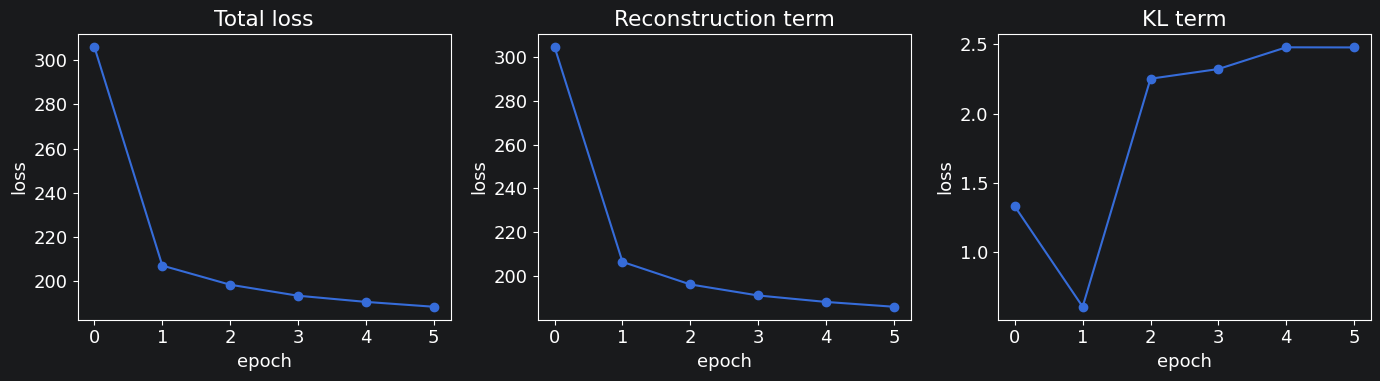

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, key, title in zip(
    axes,
    ["total", "recon", "kl"],
    ["Total loss", "Reconstruction term", "KL term"],
):
    ax.plot(history[key], marker="o")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Reconstructions, prior samples, and the latent plane

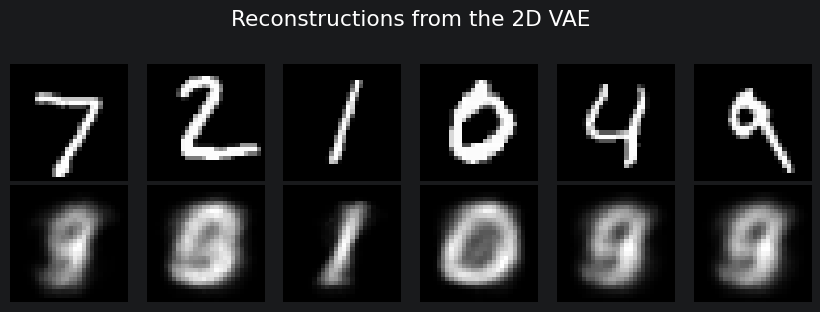

In [8]:
vae.eval()
images = example_batch.to(device)
with torch.no_grad():
    reconstructions, _, _ = vae(images)

show_image_rows(
    [images.cpu().numpy(), reconstructions.cpu().numpy()],
    ["original", "reconstruction"],
    "Reconstructions from the 2D VAE",
)

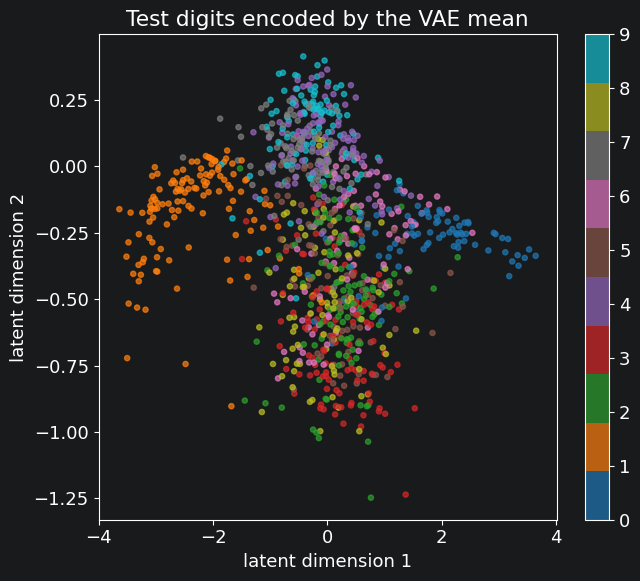

In [9]:
latent_points, latent_labels = collect_latent_means(vae, test_loader)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    latent_points[:, 0],
    latent_points[:, 1],
    c=latent_labels,
    cmap="tab10",
    s=14,
    alpha=0.7,
)
plt.xlabel("latent dimension 1")
plt.ylabel("latent dimension 2")
plt.title("Test digits encoded by the VAE mean")
plt.colorbar(scatter, ticks=range(10))
plt.tight_layout()
plt.show()

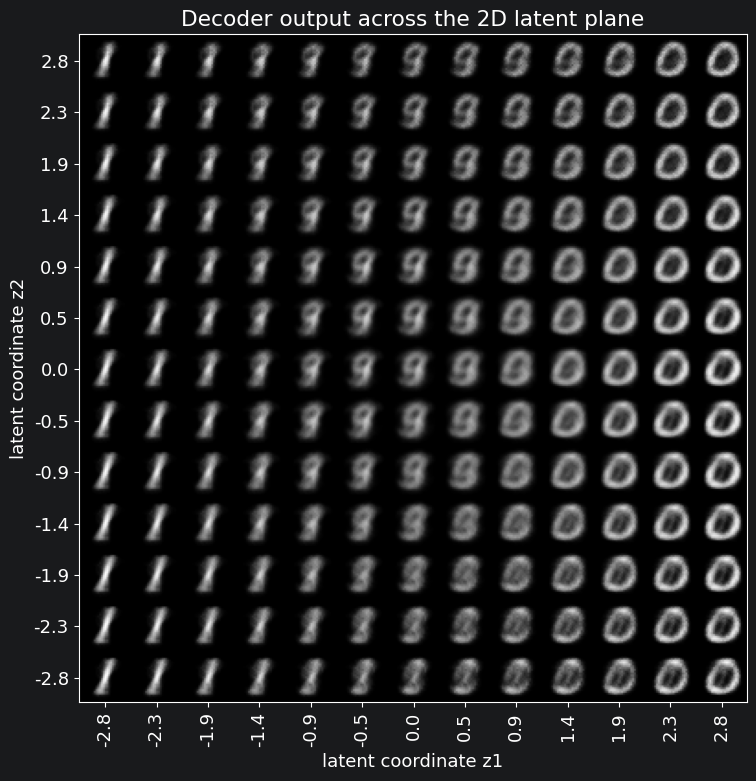

In [10]:
decode_grid(vae)

The grid plot is the main reason for using only two latent dimensions.
It lets you see whether nearby coordinates decode into gradual changes
or into disconnected artifacts.

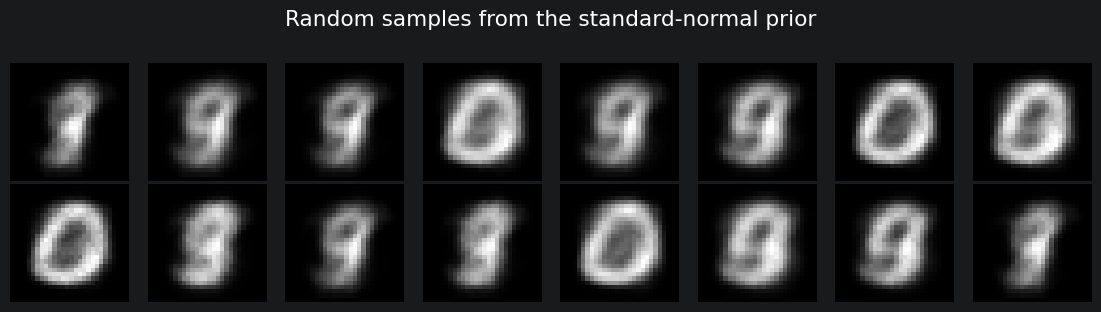

In [11]:
with torch.no_grad():
    z = torch.randn(16, LATENT_DIM, device=device)
    prior_samples = vae.decode(z).cpu().numpy()

show_image_rows([prior_samples[:8], prior_samples[8:16]], ["prior", "prior"], "Random samples from the standard-normal prior")

Prior samples are the harshest test in this notebook. They ask whether
latent points drawn from $\mathcal{N}(0, I)$ decode into plausible
digits, not just whether the model can reconstruct training examples.
After only a short run, these samples may still look rough. That is
expected. Notebook 3 makes the contrast clearer by showing what happens
when there is no KL pressure at all.

## Interactive decoder explorer

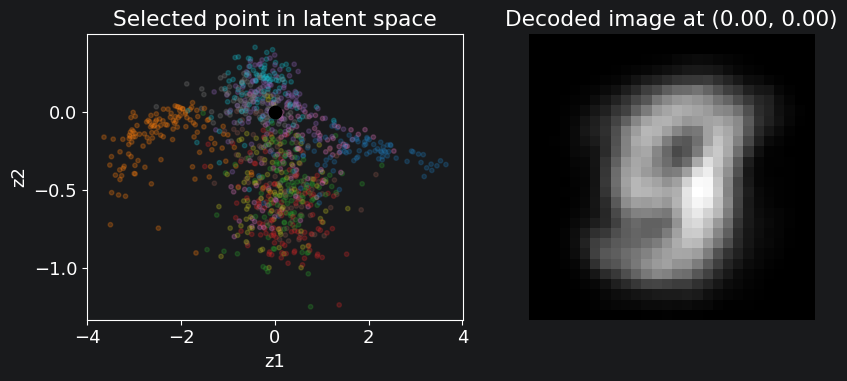

In [12]:
def inspect_latent_point(z1=0.0, z2=0.0):
    with torch.no_grad():
        z = torch.tensor([[z1, z2]], dtype=torch.float32, device=device)
        image = vae.decode(z).cpu().squeeze().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    axes[0].scatter(latent_points[:, 0], latent_points[:, 1], c=latent_labels, cmap="tab10", s=10, alpha=0.25)
    axes[0].scatter([z1], [z2], color="black", s=80)
    axes[0].set(xlabel="z1", ylabel="z2", title="Selected point in latent space")

    axes[1].imshow(image, cmap="gray")
    axes[1].set_title(f"Decoded image at ({z1:.2f}, {z2:.2f})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


inspect_latent_point()

In [13]:
widgets.interact(
    inspect_latent_point,
    z1=widgets.FloatSlider(
        value=0.0,
        min=-3.0,
        max=3.0,
        step=0.1,
        description="z1",
        layout=widgets.Layout(width="360px"),
    ),
    z2=widgets.FloatSlider(
        value=0.0,
        min=-3.0,
        max=3.0,
        step=0.1,
        description="z2",
        layout=widgets.Layout(width="360px"),
    ),
)

interactive(children=(FloatSlider(value=0.0, description='z1', layout=Layout(width='360px'), max=3.0, min=-3.0…

<function __main__.inspect_latent_point(z1=0.0, z2=0.0)>

## What to look for

- Nearby points in the latent scatter should often correspond to
  visually related digits.
- The decoder grid should change gradually across the plane rather than
  jumping randomly.
- Reconstructions are usually blurrier than a deterministic autoencoder
  with the same capacity because the VAE trades some detail for a more
  structured latent space.
- If you later increase `beta`, expect the latent plane to become more
  disciplined and the prior samples more reliable, but the
  reconstructions usually become blurrier.
- If you want cleaner reconstructions, increase the latent dimension
  later. If you want better intuition, keep it at two.
- If you still wonder why this trade-off helps with generation, compare
  the same bottleneck size against a plain autoencoder in Notebook 3.